In [11]:
import pandas as pd
import shap

from eda_package.data import DataManager
from eda_package.features import FeatureEngineer
from eda_package.preprocessor import PreprocessorManager
from eda_package.model import ModelManager
from eda_package.explainer import ExplainerManager

In [12]:
data_manager = DataManager()
feature_engineer = FeatureEngineer()
preprocessor_manager = PreprocessorManager()
model_manager = ModelManager()
explainer_manager = ExplainerManager()

preprocessor_manager.load()
model_manager.load()

X_train, X_test, y_train, y_test = data_manager.prepare_train_test_data()

In [13]:
X_train_fe = feature_engineer.engineer_features(X_train.copy())
X_test_fe = feature_engineer.engineer_features(X_test.copy())

X_train_processed = preprocessor_manager.transform(X_train_fe)
X_test_processed = preprocessor_manager.transform(X_test_fe)

feature_names = preprocessor_manager.preprocessor.get_feature_names_out()

X_train_shap = explainer_manager.transform_to_shap_df(
    X_processed=X_train_processed,
    feature_names=feature_names,
    index=X_train.index,
)

X_test_shap = explainer_manager.transform_to_shap_df(
    X_processed=X_test_processed,
    feature_names=feature_names,
    index=X_test.index,
)

In [14]:
background = X_train_shap.iloc[:50]
explainer_manager.build_explainer(model_manager, background)

In [15]:
local_result = explainer_manager.explain_local(X_test_shap.iloc[:20], row_index=0)

grouped_local = local_result["grouped_local_shap"]
grouped_local.head(10)

,feature_group,shap_value
26,room_type_mismatch,-0.218222
20,lead_time,-0.214461
5,arrival_date_year,-0.112125
13,country,-0.069161
2,agent,0.055855
21,market_segment,0.047006
6,assigned_room_type,0.040542
27,special_requests_per_guest,0.024343
16,deposit_type,-0.022355
30,total_of_special_requests,0.018592


In [16]:
higher_risk, lower_risk = explainer_manager.split_local_drivers(grouped_local, top_n=5)

print("Higher cancellation risk")
display(higher_risk)

print("Lower cancellation risk")
display(lower_risk)

Higher cancellation risk


,feature_group,shap_value
0,agent,0.055855
1,market_segment,0.047006
2,assigned_room_type,0.040542
3,special_requests_per_guest,0.024343
4,total_of_special_requests,0.018592


Lower cancellation risk


,feature_group,shap_value
0,room_type_mismatch,-0.218222
1,lead_time,-0.214461
2,arrival_date_year,-0.112125
3,country,-0.069161
4,deposit_type,-0.022355


In [17]:
global_result = explainer_manager.explain_global(X_test_shap.iloc[:20])

grouped_global = global_result["grouped_global_shap"]
grouped_global.head(15)

,feature_group,mean_abs_shap
13,country,0.171294
21,market_segment,0.085356
2,agent,0.083932
20,lead_time,0.067763
24,required_car_parking_spaces,0.057372
26,room_type_mismatch,0.048656
30,total_of_special_requests,0.037185
27,special_requests_per_guest,0.036972
14,customer_type,0.034426
16,deposit_type,0.029797


In [18]:
X_test_dates = X_test.copy()
X_test_dates["arrival_date"] = pd.to_datetime(
    X_test_dates["arrival_date_day_of_month"].astype(str)
    + " "
    + X_test_dates["arrival_date_month"].astype(str)
    + " "
    + X_test_dates["arrival_date_year"].astype(str),
    format="%d %B %Y",
    errors="coerce"
)

X_test_dates["arrival_date"].value_counts().head(10)

2017-04-13    51
2017-07-15    50
2017-07-31    48
2016-12-30    48
2017-04-29    48
2016-06-26    47
2017-05-05    44
2015-08-10    42
2017-08-07    42
2016-10-06    41
Name: arrival_date, dtype: int64

In [19]:
date_result = explainer_manager.explain_global_for_date(
    selected_date="2017-07-15",
    X_raw=X_test,
    feature_engineer=feature_engineer,
    preprocessor_manager=preprocessor_manager,
    min_rows=5,
)

print(date_result["n_bookings"])
print(date_result["message"])

if date_result["grouped_global_shap"] is not None:
    display(date_result["grouped_global_shap"].head(15))

50
None


,feature_group,mean_abs_shap
13,country,0.168558
20,lead_time,0.091220
2,agent,0.088770
21,market_segment,0.074497
30,total_of_special_requests,0.045551
27,special_requests_per_guest,0.042817
24,required_car_parking_spaces,0.035688
14,customer_type,0.035644
5,arrival_date_year,0.027527
26,room_type_mismatch,0.024662


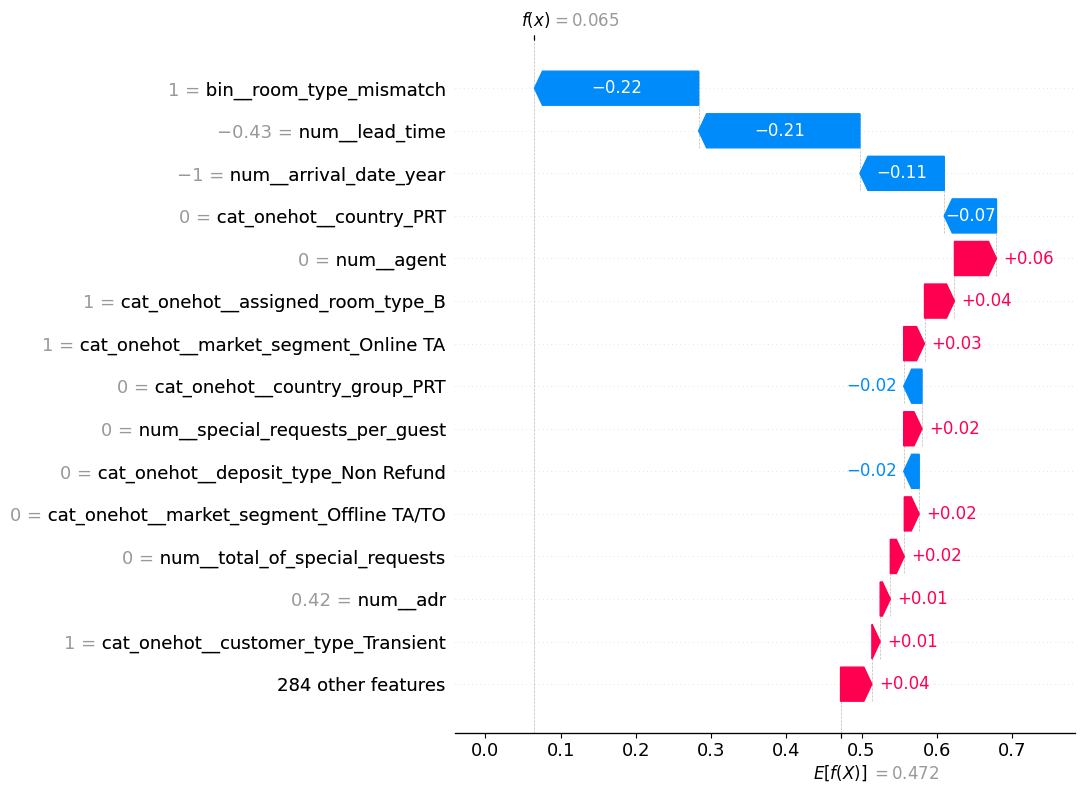

In [20]:
local_shap_values = local_result["shap_values"]
shap.plots.waterfall(local_shap_values[0], max_display=15)

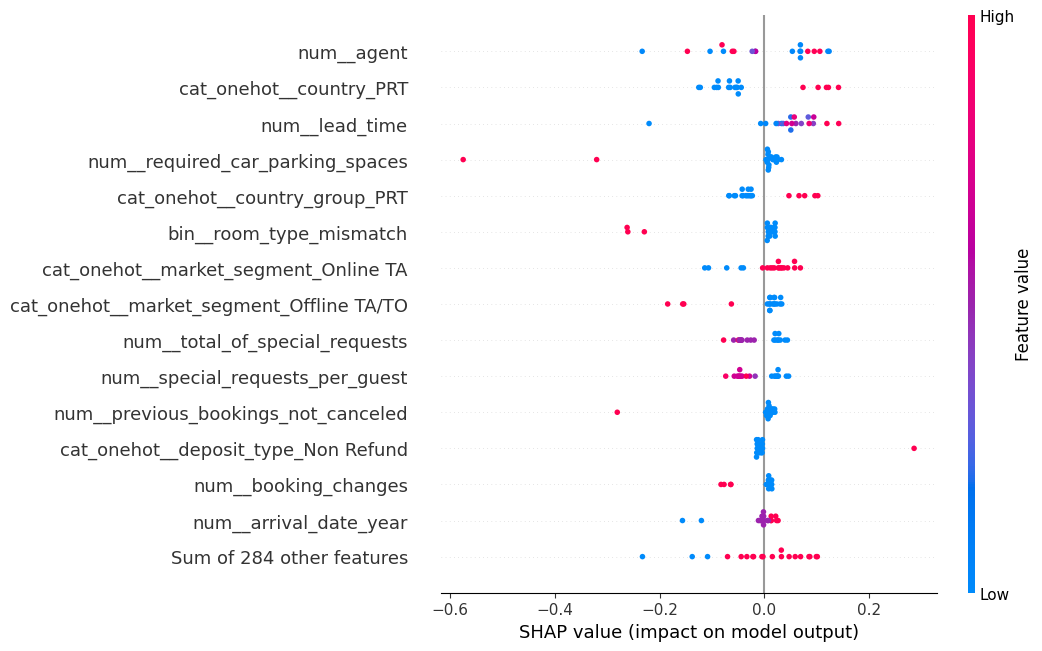

In [21]:
global_shap_values = global_result["shap_values"]
shap.plots.beeswarm(global_shap_values, max_display=15)